## Introduction to convollution neural network

In [1]:
import logging
logger = logging.getLogger()
logger.setLevel(logging.DEBUG)

In [3]:
import sys
import cv2
import time
import torch
import torch .nn as nn
import torch.optim as optim
import torch.nn.functional as F 
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
from matplotlib import pyplot as plt
from sklearn.datasets import fetch_openml
print('OS:', sys.platform)
print('Numpy:', np.__version__)
print("Python:",sys.version)
print("pytorch:",torch.__version__)
print("CUDA:", torch.cuda.is_available())


OS: win32
Numpy: 2.5.3
Python: 3.13.14 (tags/v3.13.14:fd17997, Jun 10 2026, 13:03:48) [MSC v.1944 64 bit (AMD64)]
pytorch: 2.14.0+cpu
CUDA: False


### Convolution method

In [4]:
def plot_image(image,image2 = None):
    plt.subplot(121)
    if len(image.shape) == 3:
        image = cv2.cvtColor(image,cv2.COLOR_BGR2RGB)
        plt.imshow(image)
    else:
        plt.imshow(image,cmap = plt.get_cmap("gray"))
    plt.axis("off")
    if image2 is not None:
        plt.subplot(122)
        if len(image2.shape) == 3:
            image2 = cv2.cvtColor(image2,cv2.COLOR_BGR2RGB)
            plt.imshow(image2)
        else:
            plt.imshow(image2,cmap=plt.get_cmap("gray"))
        plt.axis("off")
    plt.show()
        

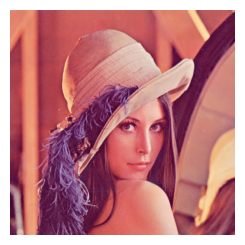

In [6]:
im = cv2.imread("Lenna.png")
plot_image(im)

### Filters applying using cv2.filters2D

In [7]:
shapen = np.array(([0,-1,0],[-1,5,-1],[0,-1,0]),dtype = int)
lapalacian = np.array(([0,1,0],[1,-4,1],[0,1,0]), dtype = int)
sobelX = np.array(([-1,0,1],[-2,0,2],[-1,0,1]))
sobelY = np.array(([-1,-2,-1], [0,0,0],[1,2,1]), dtype= int)

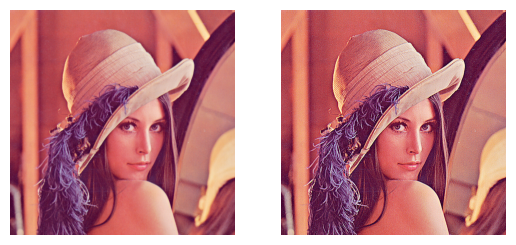

In [9]:
dst = cv2.filter2D(im, -1, shapen)
plot_image(im,dst)

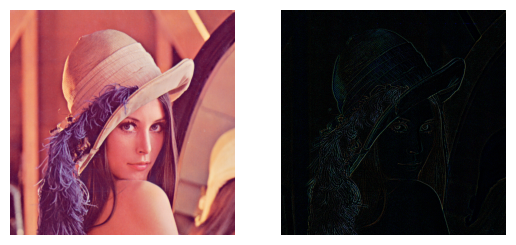

In [11]:
dst = cv2.filter2D(im, -1, lapalacian)
plot_image(im,dst)

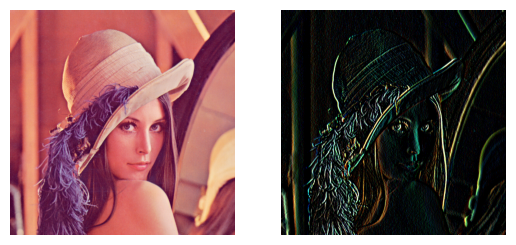

In [13]:
dst = cv2.filter2D(im, -1, sobelX)
plot_image(im,dst)

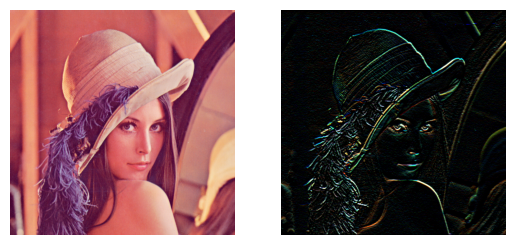

In [14]:
dst = cv2.filter2D(im, -1, sobelY)
plot_image(im,dst)

### digit recognition by NMIST dataset

In [15]:
mnist = fetch_openml("mnist_784", version = 1)

In [17]:
X = mnist.data.to_numpy()
Y = mnist.target.to_numpy()

#### Shuffel the data

In [18]:
np.random.seed(1234)
p = np.random.permutation(X.shape[0]) #get permutataion of indices
#normalize the data by converting the image intensities to 0.0 - 1.0
X = X[p].astype(np.float32)/255
Y = Y[p].astype(int)

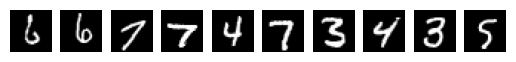

In [19]:
for i in range(10): # since there are 10 classes
    plt.subplot(1,10,i+1)
    plt.imshow(X[i].reshape((28,28)), cmap = "gray")
    plt.axis("off")
plt.show()

#### Splitting the data for train test split and reshape to pytorch format (batch_size, channels, height,width)


In [20]:
X_train = X[:60000].reshape((-1,1,28,28))
X_test = X[60000:].reshape((-1,1,28,28))
Y_train = Y[:60000]
Y_test = Y[60000:]

#### Creating python dataset and the loaders


In [21]:
batch_size = 100

In [22]:
train_dataset = TensorDataset(torch.tensor(X_train), torch.tensor(Y_train))
test_dataset = TensorDataset(torch.tensor(X_test), torch.tensor(Y_test))

In [23]:
train_loader = DataLoader(train_dataset,batch_size = batch_size,shuffle=True)
test_loader = DataLoader(test_dataset, batch_size = batch_size, shuffle = False)

#### LeNet architecture


In [24]:
class LeNet(nn.Module):
    def __init__(self):
        super(LeNet,self).__init__()
        #this is the 1st conv layer 20 o/p feature maps and 5x5 kernel
        self.conv1 = nn.Conv2d(1,20,kernel_size=5)
        #20 i/p feature map 50 o/p feature mamp 5x5 kernel
        self.conv2 = nn.Conv2d(20,50,kernel_size=5)
        #fc1 50 filters with 4x4 feature map after pooling
        self.fc1 = nn.Linear(50 * 4 * 4, 500)
        #fc2 500 input features, 10 output features for 10 classes
        self.fc2 = nn.Linear(500,10)
    def forward(self,x):
        x = torch.tanh(self.conv1(x))
        x = F.max_pool2d(x,2)
        x = torch.tanh(self.conv2(x))
        x = F.max_pool2d(x,2)
        x = x.view(-1,50 * 4 * 4)
        x = torch.tanh(self.fc1(x))
        x = self.fc2(x)
        return F.log_softmax(x,dim=1)
model =LeNet()
        

#### Traning the model which we prepaired in previous cell

In [25]:
device  = torch.device ("cuda" if torch.cuda.is_available() else "cpu")
print(device)
model.to(device)

cpu


LeNet(
  (conv1): Conv2d(1, 20, kernel_size=(5, 5), stride=(1, 1))
  (conv2): Conv2d(20, 50, kernel_size=(5, 5), stride=(1, 1))
  (fc1): Linear(in_features=800, out_features=500, bias=True)
  (fc2): Linear(in_features=500, out_features=10, bias=True)
)

In [26]:
optimizer = optim.SGD(model.parameters(), lr = 0.1, momentum=0.9, weight_decay= 1e-5)
criterion = nn.CrossEntropyLoss()


#### Training Loop

In [33]:
def train(model, device, train_loader,optimizer, epoch):
    model.train()
    for batch_idx, (data, target) in enumerate(train_loader):
        data,target = data.to(device), target.to(device)
        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()
        if batch_idx % 200 == 0:
            print(f"Train Eposch{epoch} [{batch_idx * len(data)}/{len(train_loader.dataset)}"
                  f"({100. * batch_idx / len(train_loader):.0f}%)]\tLoss: {loss.item():.6f}")
        

#### Testing Loop

In [34]:
def test(model, device, test_loader):
    model.eval()
    test_loss = 0
    correct = 0
    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            test_loss += criterion(output, target).item()  # Sum up batch loss
            pred = output.argmax(
                dim=1, keepdim=True
            )  # Get the index of the max log-probability
            correct += pred.eq(target.view_as(pred)).sum().item()

    test_loss /= len(test_loader.dataset)
    print(
        f"\nTest set: Average loss: {test_loss:.4f}, Accuracy: {correct}/{len(test_loader.dataset)} "
        f"({100. * correct / len(test_loader.dataset):.0f}%)\n"
    )


# Train for 10 epochs
for epoch in range(1, 11):
    train(model, device, train_loader, optimizer, epoch)
    test(model, device, test_loader)


Train Eposch1 [0/60000(0%)]	Loss: 2.304231
Train Eposch1 [20000/60000(33%)]	Loss: 0.162696
Train Eposch1 [40000/60000(67%)]	Loss: 0.026300

Test set: Average loss: 0.0008, Accuracy: 9794/10000 (98%)

Train Eposch2 [0/60000(0%)]	Loss: 0.061889
Train Eposch2 [20000/60000(33%)]	Loss: 0.027524
Train Eposch2 [40000/60000(67%)]	Loss: 0.027442

Test set: Average loss: 0.0007, Accuracy: 9823/10000 (98%)

Train Eposch3 [0/60000(0%)]	Loss: 0.038723
Train Eposch3 [20000/60000(33%)]	Loss: 0.035019
Train Eposch3 [40000/60000(67%)]	Loss: 0.069103

Test set: Average loss: 0.0007, Accuracy: 9830/10000 (98%)

Train Eposch4 [0/60000(0%)]	Loss: 0.029677
Train Eposch4 [20000/60000(33%)]	Loss: 0.005172
Train Eposch4 [40000/60000(67%)]	Loss: 0.005061

Test set: Average loss: 0.0006, Accuracy: 9851/10000 (99%)

Train Eposch5 [0/60000(0%)]	Loss: 0.018292
Train Eposch5 [20000/60000(33%)]	Loss: 0.005684
Train Eposch5 [40000/60000(67%)]	Loss: 0.008657

Test set: Average loss: 0.0005, Accuracy: 9855/10000 (99%)

